In [22]:
!pip install numpy pandas matplotlib scikit-learn scikit-image opencv-python \
             scikit-fuzzy tqdm joblib scipy staintools spams

  Using cached staintools-2.1.2-py3-none-any.whl
  Using cached spams-2.6.5.4.tar.gz (2.0 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for spams (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for spams
Failed to build spams
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (spams)


In [23]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile, os

tar_path     = "/content/drive/MyDrive/BreaKHis_v1.tar.gz"
extract_path = "/content/BreaKHis"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("Extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_11459/2547009006.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete!


In [24]:
import numpy as np
import pandas as pd
import cv2
import os
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew, kurtosis, mode as scipy_mode

import skfuzzy as fuzz

print("All imports successful.")

All imports successful.


In [25]:
def build_dataset(root):
    """Walk BreaKHis directory tree and collect image metadata."""
    data = []
    for root_dir, _, files in os.walk(root):
        for file in files:
            if not file.endswith(".png"):
                continue
            path = os.path.join(root_dir, file)
            label      = 0 if "benign" in path else 1
            patient_id = path.split("_")[2]   # e.g. "14134"

            if   "40X"  in path: mag = "40X"
            elif "100X" in path: mag = "100X"
            elif "200X" in path: mag = "200X"
            else:                mag = "400X"

            data.append([path, label, patient_id, mag])

    df = pd.DataFrame(data, columns=["path", "label", "patient", "mag"])
    return df

df = build_dataset(extract_path)
print(df.head())
print("Total samples :", len(df))
print("Class distribution:\n", df["label"].value_counts().rename({0:"Benign", 1:"Malignant"}))
print("Magnifications :\n", df["mag"].value_counts())

                                                path  label  \
0  /content/BreaKHis/BreaKHis_v1/histology_slides...      0   
1  /content/BreaKHis/BreaKHis_v1/histology_slides...      0   
2  /content/BreaKHis/BreaKHis_v1/histology_slides...      0   
3  /content/BreaKHis/BreaKHis_v1/histology_slides...      0   
4  /content/BreaKHis/BreaKHis_v1/histology_slides...      0   

                                 patient   mag  
0  slides/breast/benign/SOB/adenosis/SOB  400X  
1  slides/breast/benign/SOB/adenosis/SOB  400X  
2  slides/breast/benign/SOB/adenosis/SOB  400X  
3  slides/breast/benign/SOB/adenosis/SOB  400X  
4  slides/breast/benign/SOB/adenosis/SOB  400X  
Total samples : 7909
Class distribution:
 label
Malignant    5429
Benign       2480
Name: count, dtype: int64
Magnifications :
 mag
100X    2081
200X    2013
40X     1995
400X    1820
Name: count, dtype: int64


In [26]:
# Macenko et al. (2009): SVD-based stain vector estimation.
# We implement a self-contained version so staintools is only a fallback.

def macenko_normalise(img, target_mu=None, target_sigma=None,
                      beta=0.15, alpha=1.0):
    """
    Macenko stain normalisation (BGR uint8 in → BGR uint8 out).

    Parameters
    ----------
    img          : BGR uint8 image
    target_mu    : target mean of stain concentrations (fitted on reference)
    target_sigma : target std  of stain concentrations (fitted on reference)
    beta         : OD threshold for background removal
    alpha        : percentile for robust angle estimation

    Returns
    -------
    normalised BGR image, stain_mu, stain_sigma
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

    # Convert to optical density
    img_rgb = np.clip(img_rgb, 1, 255)
    OD = -np.log(img_rgb / 255.0)

    # Remove background pixels (low OD)
    OD_hat = OD[np.all(OD > beta, axis=2)]

    if len(OD_hat) < 10:          # fallback: too few tissue pixels
        return img, np.zeros(2), np.ones(2)

    # SVD on covariance of OD pixels
    cov = np.cov(OD_hat.T)
    _, V = np.linalg.eigh(cov)
    V = V[:, -2:]                  # top-2 eigenvectors (3×2)

    # Project onto 2D plane and find extreme angles
    that = OD_hat @ V
    phi  = np.arctan2(that[:, 1], that[:, 0])

    min_phi = np.percentile(phi, alpha)
    max_phi = np.percentile(phi, 100 - alpha)

    v1 = V @ np.array([np.cos(min_phi), np.sin(min_phi)])
    v2 = V @ np.array([np.cos(max_phi), np.sin(max_phi)])

    # Heuristic: haematoxylin has larger blue component
    if v1[0] > v2[0]:
        v1, v2 = v2, v1

    HE = np.stack([v1, v2], axis=1)    # 3×2 stain matrix

    # Deconvolve to get stain concentrations
    HE_pinv = np.linalg.pinv(HE)       # 2×3
    OD_flat = OD.reshape(-1, 3).T      # 3×N
    C = HE_pinv @ OD_flat              # 2×N

    mu    = np.percentile(C, 99, axis=1)
    sigma = C.std(axis=1) + 1e-6

    # Normalise to target distribution
    if target_mu is None or target_sigma is None:
        return img, mu, sigma          # first call: return reference stats

    C_norm = ((C - mu[:, None]) / sigma[:, None]) * target_sigma[:, None] \
             + target_mu[:, None]

    # Reconstruct normalised image
    OD_norm = HE @ np.clip(C_norm, 0, None)
    img_norm = np.exp(-OD_norm.T.reshape(img.shape[0], img.shape[1], 3))
    img_norm = np.clip(img_norm * 255, 0, 255).astype(np.uint8)
    img_norm = cv2.cvtColor(img_norm, cv2.COLOR_RGB2BGR)
    return img_norm, mu, sigma


# --- Fit reference statistics on a randomly chosen reference image -----------
_ref_path  = df.sample(1, random_state=42).iloc[0]["path"]
_ref_img   = cv2.imread(_ref_path)
_ref_img   = cv2.resize(_ref_img, (224, 224))
_, REF_MU, REF_SIGMA = macenko_normalise(_ref_img)

print(f"Reference image : {os.path.basename(_ref_path)}")
print(f"Reference mu    : {REF_MU}")
print(f"Reference sigma : {REF_SIGMA}")

Reference image : SOB_M_LC-14-15570C-40-003.png
Reference mu    : [1.18072584 0.64393782]
Reference sigma : [0.23633039 0.21172379]


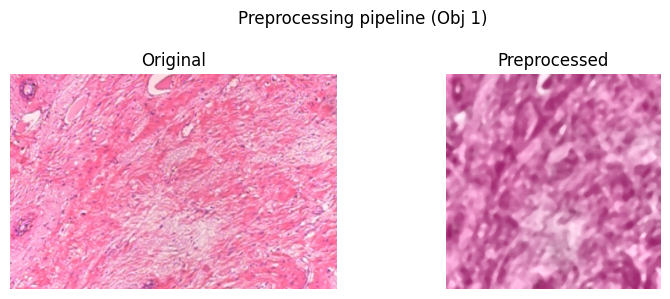

Preprocessing sanity check saved.


In [27]:
def preprocess(img):
    """
    Full preprocessing pipeline (Objective 1):
      1. Resize to 224×224
      2. Macenko stain normalisation
      3. Gaussian + Median blur  (noise reduction)
      4. CLAHE on L-channel      (contrast enhancement)
      5. Intensity normalisation via LAB
    """
    # 1. Resize
    img = cv2.resize(img, (224, 224))

    # 2. Macenko stain normalisation (Objective 1 — primary gap fix)
    img, _, _ = macenko_normalise(img, target_mu=REF_MU, target_sigma=REF_SIGMA)

    # 3. Noise reduction — Gaussian followed by Median
    img = cv2.GaussianBlur(img, (5, 5), 1)
    img = cv2.medianBlur(img, 5)

    # 4 & 5. Contrast enhancement + intensity normalisation via LAB/CLAHE
    lab   = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l     = clahe.apply(l)
    img   = cv2.merge((l, a, b))
    img   = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    return img


# Quick sanity check — show before/after for one image
_sample = cv2.imread(_ref_path)
_proc   = preprocess(_sample.copy())
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(cv2.cvtColor(_sample,  cv2.COLOR_BGR2RGB)); axes[0].set_title("Original");    axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(_proc,    cv2.COLOR_BGR2RGB)); axes[1].set_title("Preprocessed"); axes[1].axis("off")
plt.suptitle("Preprocessing pipeline (Obj 1)", fontsize=12)
plt.tight_layout(); plt.savefig("preprocessing_check.png", dpi=120); plt.show()
print("Preprocessing sanity check saved.")

In [28]:
def extract_features(img):
    """
    Extract handcrafted features from a preprocessed BGR image (Objective 2).

    Feature groups
    --------------
    GLCM        : contrast, homogeneity, energy, correlation
                  distances=[1,3,5], angles=[0,π/4,π/2,3π/4] → 4×12 = 48 feats
    LBP         : radii 1,2,3 — histogram with 10 bins each → 30 feats
    Gabor       : 6 orientations × 4 frequencies × (mean+std) → 48 feats
    Morphology  : Otsu contours: count, mean/std/max area,
                  solidity, extent, perimeter stats → 10 feats
    Statistical : mean, std, skew, kurtosis per BGR channel → 12 feats
    Total       : 148 features
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = []

    # ── GLCM ──────────────────────────────────────────────────────────────────
    glcm = graycomatrix(gray, [1, 3, 5],
                        [0, np.pi/4, np.pi/2, 3*np.pi/4],
                        256, symmetric=True, normed=True)
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        features.extend(graycoprops(glcm, prop).flatten())   # 3×4 = 12 per prop

    # ── LBP ───────────────────────────────────────────────────────────────────
    for r in [1, 2, 3]:
        lbp  = local_binary_pattern(gray, 8*r, r, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=10, density=True)
        features.extend(hist)

    # ── Gabor ─────────────────────────────────────────────────────────────────
    for theta in np.arange(0, np.pi, np.pi/6):          # 6 orientations
        for freq in [0.1, 0.2, 0.3, 0.4]:               # 4 frequencies
            kernel = cv2.getGaborKernel((9, 9), 4.0, theta, freq, 0.5, 0)
            fimg   = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
            features.append(float(fimg.mean()))
            features.append(float(fimg.std()))

    # ── Morphological (extended — Obj 2 gap fix) ──────────────────────────────
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours if cv2.contourArea(c) > 10]

    if len(valid) == 0:
        features += [0] * 10
    else:
        areas      = [cv2.contourArea(c) for c in valid]
        perimeters = [cv2.arcLength(c, True) for c in valid]
        solidities, extents = [], []
        for c in valid:
            area = cv2.contourArea(c)
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            solidity  = area / hull_area if hull_area > 0 else 0
            x, y, w, h = cv2.boundingRect(c)
            extent    = area / (w * h) if w * h > 0 else 0
            solidities.append(solidity)
            extents.append(extent)

        features += [
            len(valid),
            np.mean(areas),   np.std(areas),   np.max(areas),
            np.mean(perimeters),
            np.mean(solidities),
            np.mean(extents),
            np.mean(areas) / (np.mean(perimeters)**2 + 1e-6),  # circularity proxy
            np.std(solidities),
            np.std(extents),
        ]

    # ── Statistical intensity (per BGR channel) ────────────────────────────────
    for i in range(3):
        ch = img[:, :, i].flatten().astype(np.float32)
        features += [np.mean(ch), np.std(ch), float(skew(ch)), float(kurtosis(ch))]

    return features

In [29]:
def extract_all_features(df):
    """Extract features for every image; track magnification label."""
    X, y, patients, mags = [], [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
        img  = cv2.imread(row["path"])
        img  = preprocess(img)
        feat = extract_features(img)

        X.append(feat)
        y.append(row["label"])
        patients.append(row["patient"])
        mags.append(row["mag"])

    return (np.array(X, dtype=np.float32),
            np.array(y),
            np.array(patients),
            np.array(mags))


X, y, patients, mags = extract_all_features(df)
print(f"Feature matrix shape : {X.shape}   (samples × features)")
print(f"Class counts          : Benign={np.sum(y==0)}, Malignant={np.sum(y==1)}")


Extracting features: 100%|██████████| 7909/7909 [19:12<00:00,  6.86it/s]


Feature matrix shape : (7909, 148)   (samples × features)
Class counts          : Benign=2480, Malignant=5429


In [30]:
unique_patients = np.unique(patients)

# Assign each patient a majority label
patient_labels = np.array([
    int(np.mean(y[patients == p]) > 0.5) for p in unique_patients
])

print(f"Total patients        : {len(unique_patients)}")
print(f"Patient class counts  : Benign={np.sum(patient_labels==0)}, "
      f"Malignant={np.sum(patient_labels==1)}")

# Enforce 5-fold: requires at least 5 patients per class.
# BreaKHis has sufficient patients; if a custom subset is too small, fall back.
min_class = min(np.sum(patient_labels == 0), np.sum(patient_labels == 1))
N_SPLITS  = 5 if min_class >= 5 else min_class
if N_SPLITS < 5:
    print(f"WARNING: only {min_class} patients in minority class — "
          f"using {N_SPLITS}-fold instead of 5.")
else:
    print(f"Using {N_SPLITS}-fold patient-level stratified CV (Objective 5).")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

Total patients        : 8
Patient class counts  : Benign=4, Malignant=4


In [31]:
def align_labels(pred, true):
    """
    Map cluster IDs to clinical labels by majority vote within each cluster.
    Returns aligned predictions.
    """
    aligned = np.zeros_like(pred)
    for cluster_id in np.unique(pred):
        mask = pred == cluster_id
        majority = int(scipy_mode(true[mask], keepdims=True).mode[0])
        aligned[mask] = majority
    return aligned

In [32]:
def compute_metrics(X_space, true_labels, pred_labels, prefix):
    """
    Compute internal validity indices and post-hoc clinical metrics.

    Internal  : Silhouette, Davies-Bouldin, Calinski-Harabasz
    Post-hoc  : Accuracy, Sensitivity (Recall), Specificity, F1
    """
    aligned = align_labels(pred_labels, true_labels)

    sil = silhouette_score(X_space, pred_labels)
    db  = davies_bouldin_score(X_space, pred_labels)
    ch  = calinski_harabasz_score(X_space, pred_labels)

    acc  = accuracy_score(true_labels, aligned)
    sens = recall_score(true_labels, aligned, zero_division=0)
    f1   = f1_score(true_labels, aligned, zero_division=0)

    cm = confusion_matrix(true_labels, aligned)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        spec = 0.0

    return {
        f"{prefix}_sil" : sil,
        f"{prefix}_db"  : db,
        f"{prefix}_ch"  : ch,
        f"{prefix}_acc" : acc,
        f"{prefix}_sens": sens,
        f"{prefix}_spec": spec,
        f"{prefix}_f1"  : f1,
    }


In [33]:
def run_fold(train_idx, test_idx, fold_num):
    """
    One CV fold:
      - Z-score + PCA             (Objective 3)
      - KMeans grid search k=2..9 (Objective 4 & 5)
      - FCM grid search c=2..5,
        m=1.5,2.0,2.5             (Objective 4 & 5 — gap fix)
      - Full metric suite         (Objective 6)
    """
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx],  y[test_idx]

    # ── Objective 3: Z-score normalisation ────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Objective 3: PCA dimensionality reduction ──────────────────────────────
    pca     = PCA(n_components=0.95, random_state=42)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)
    n_comp  = pca.n_components_
    var_exp = pca.explained_variance_ratio_.sum()
    print(f"  Fold {fold_num} — PCA: {n_comp} components, "
          f"{var_exp*100:.1f}% variance retained")

    # ── Objective 4 & 5: KMeans hyperparameter grid search ────────────────────
    best_km_score, best_km, best_k = -1, None, 2
    for k in range(2, 10):
        km     = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=500)
        labels = km.fit_predict(X_train)
        score  = silhouette_score(X_train, labels)
        if score > best_km_score:
            best_km_score, best_km, best_k = score, km, k

    km_labels = best_km.predict(X_test)
    print(f"  Fold {fold_num} — Best KMeans k={best_k} "
          f"(train sil={best_km_score:.4f})")

    # ── Objective 4 & 5: FCM hyperparameter grid search (gap fix) ─────────────
    best_fcm_score, best_fcm_labels = -1, None
    best_c, best_m = 2, 2.0

    for c in range(2, 6):           # c ∈ {2,3,4,5}
        for m in [1.5, 2.0, 2.5]:  # fuzziness
            try:
                cntr, u, *_ = fuzz.cluster.cmeans(
                    X_train.T, c=c, m=m, error=0.005, maxiter=1000)
                train_labels = np.argmax(u, axis=0)
                if len(np.unique(train_labels)) < 2:
                    continue
                score = silhouette_score(X_train, train_labels)
                if score > best_fcm_score:
                    best_fcm_score = score
                    best_c, best_m = c, m
                    # Store best centres for prediction
                    best_cntr = cntr
            except Exception:
                continue

    # Predict on test set using best FCM centres
    u_test, *_ = fuzz.cluster.cmeans_predict(
        X_test.T, best_cntr, m=best_m, error=0.005, maxiter=1000)
    fcm_labels = np.argmax(u_test, axis=0)
    print(f"  Fold {fold_num} — Best FCM c={best_c}, m={best_m} "
          f"(train sil={best_fcm_score:.4f})")

    # ── Objective 6: Full metric suite ────────────────────────────────────────
    km_metrics  = compute_metrics(X_test, y_test, km_labels,  "km")
    fcm_metrics = compute_metrics(X_test, y_test, fcm_labels, "fcm")

    fold_result = {
        "fold"   : fold_num,
        "n_pca"  : n_comp,
        "var_exp": round(var_exp, 4),
        "best_k" : best_k,
        "best_c" : best_c,
        "best_m" : best_m,
        **km_metrics,
        **fcm_metrics,
    }
    return fold_result

In [34]:
results = []
print(f"\nRunning {N_SPLITS}-fold patient-level stratified CV …\n")

for fold_i, (train_p_idx, test_p_idx) in enumerate(
        skf.split(unique_patients, patient_labels), start=1):

    train_patients = unique_patients[train_p_idx]
    test_patients  = unique_patients[test_p_idx]

    train_mask = np.isin(patients, train_patients)
    test_mask  = np.isin(patients, test_patients)

    print(f"Fold {fold_i} | "
          f"train images={train_mask.sum()}, test images={test_mask.sum()}")

    res = run_fold(np.where(train_mask)[0], np.where(test_mask)[0], fold_i)
    results.append(res)
    print()

results_df = pd.DataFrame(results)
print("\n=== PER-FOLD RESULTS ===")
print(results_df.to_string(index=False))


Running 4-fold patient-level stratified CV …

Fold 1 | train images=6664, test images=1245
  Fold 1 — PCA: 21 components, 95.1% variance retained
  Fold 1 — Best KMeans k=2 (train sil=0.2446)
  Fold 1 — Best FCM c=2, m=1.5 (train sil=0.1684)

Fold 2 | train images=4014, test images=3895
  Fold 2 — PCA: 21 components, 95.1% variance retained
  Fold 2 — Best KMeans k=2 (train sil=0.2342)
  Fold 2 — Best FCM c=2, m=1.5 (train sil=0.2104)

Fold 3 | train images=6780, test images=1129
  Fold 3 — PCA: 22 components, 95.4% variance retained
  Fold 3 — Best KMeans k=2 (train sil=0.2385)
  Fold 3 — Best FCM c=2, m=1.5 (train sil=0.1721)

Fold 4 | train images=6269, test images=1640
  Fold 4 — PCA: 21 components, 95.0% variance retained
  Fold 4 — Best KMeans k=4 (train sil=0.1824)
  Fold 4 — Best FCM c=2, m=2.0 (train sil=0.1647)


=== PER-FOLD RESULTS ===
 fold  n_pca  var_exp  best_k  best_c  best_m   km_sil    km_db      km_ch   km_acc  km_sens  km_spec    km_f1  fcm_sil   fcm_db     fcm_ch

In [35]:
metric_cols = [c for c in results_df.columns
               if c not in ("fold", "n_pca", "var_exp", "best_k", "best_c", "best_m")]

summary = results_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["Mean", "Std"]
summary.index.name = "Metric"

print("\n=== FINAL SUMMARY (Mean ± Std across folds) ===\n")
for idx, row in summary.iterrows():
    print(f"  {idx:<20} {row['Mean']:.4f} ± {row['Std']:.4f}")

summary.to_csv("summary_results.csv")
results_df.to_csv("fold_results.csv", index=False)
print("\nCSVs saved.")


=== FINAL SUMMARY (Mean ± Std across folds) ===

  km_sil               0.2197 ± 0.0450
  km_db                1.8113 ± 0.1378
  km_ch                427.9599 ± 296.2736
  km_acc               0.6871 ± 0.1559
  km_sens              0.7439 ± 0.1939
  km_spec              0.4084 ± 0.3453
  km_f1                0.7087 ± 0.1669
  fcm_sil              0.1740 ± 0.0376
  fcm_db               2.0328 ± 0.1474
  fcm_ch               399.6286 ± 301.7151
  fcm_acc              0.6854 ± 0.1349
  fcm_sens             0.7640 ± 0.2747
  fcm_spec             0.3400 ± 0.3930
  fcm_f1               0.6993 ± 0.1954

CSVs saved.


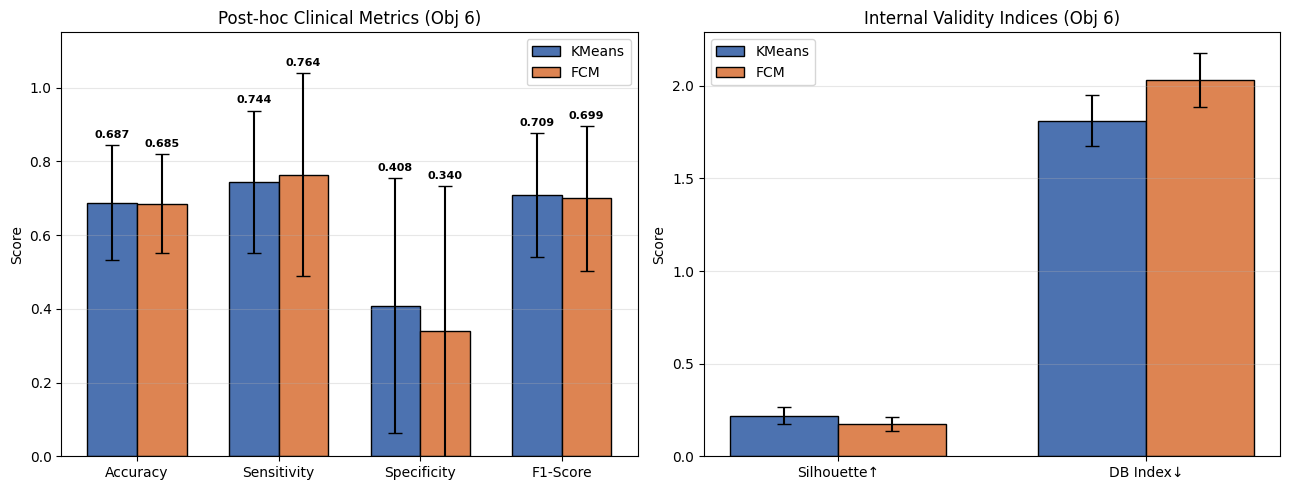

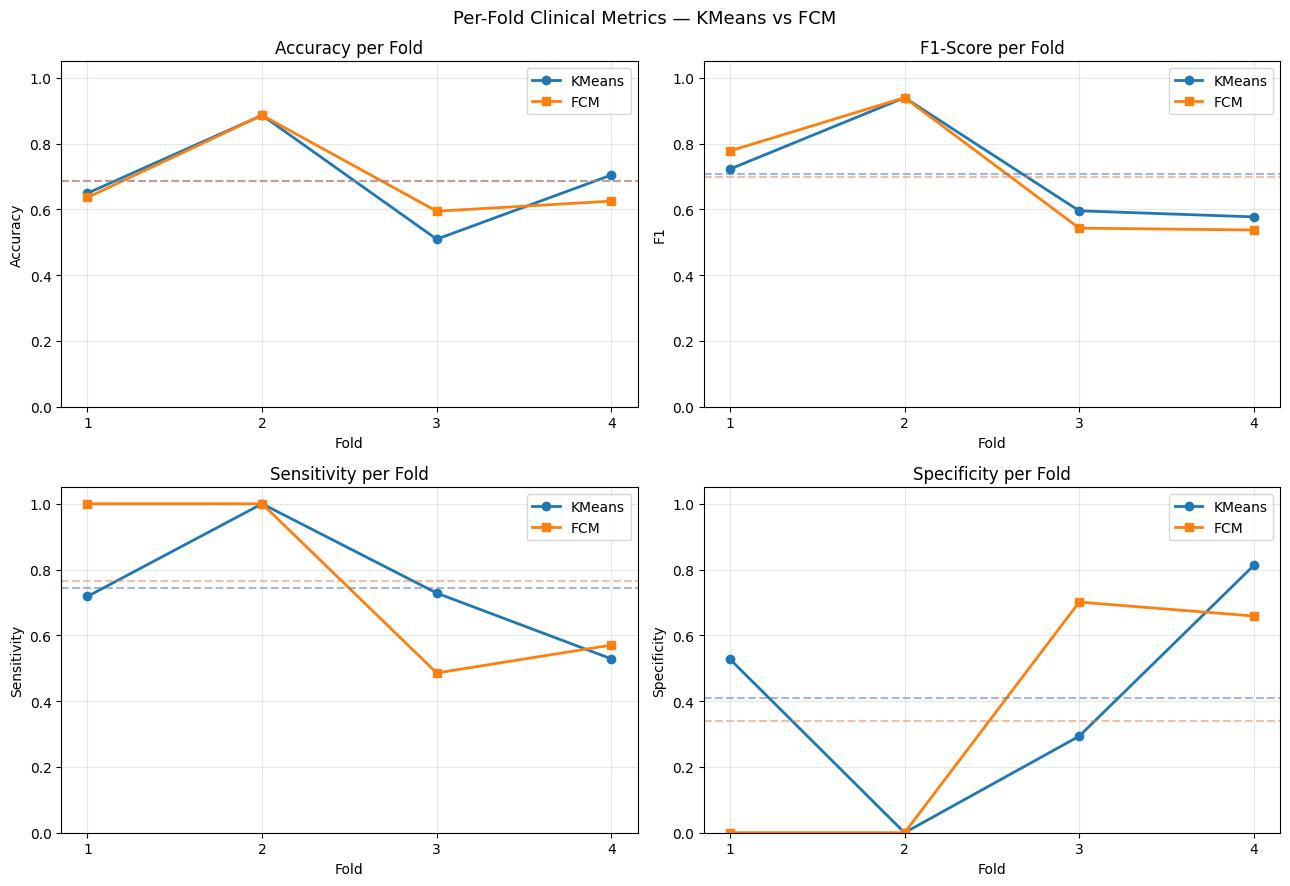

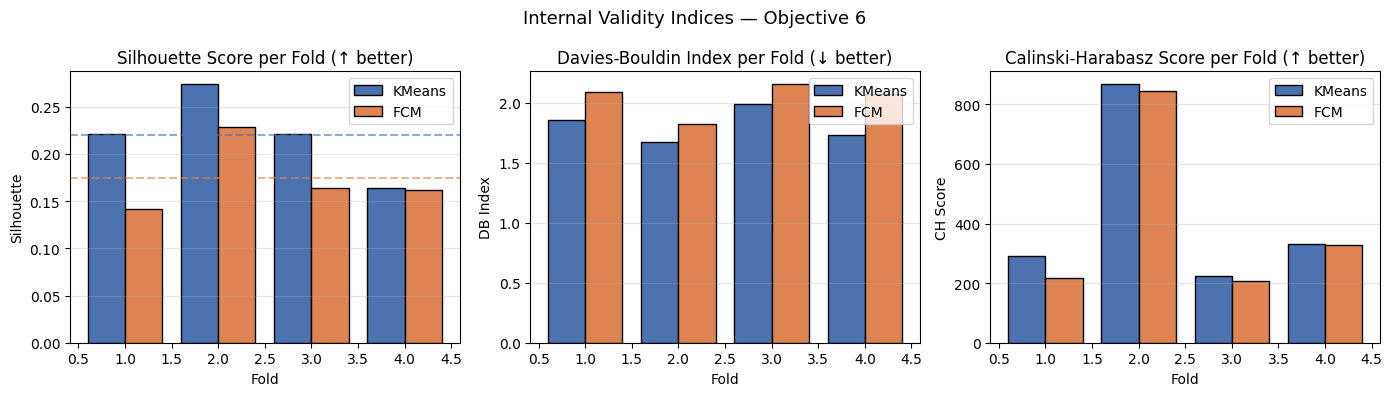

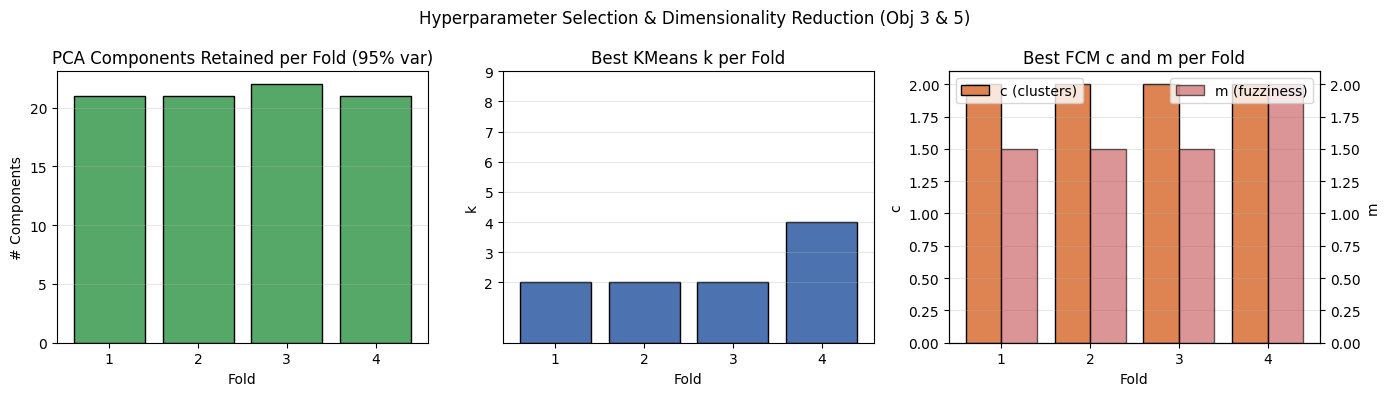

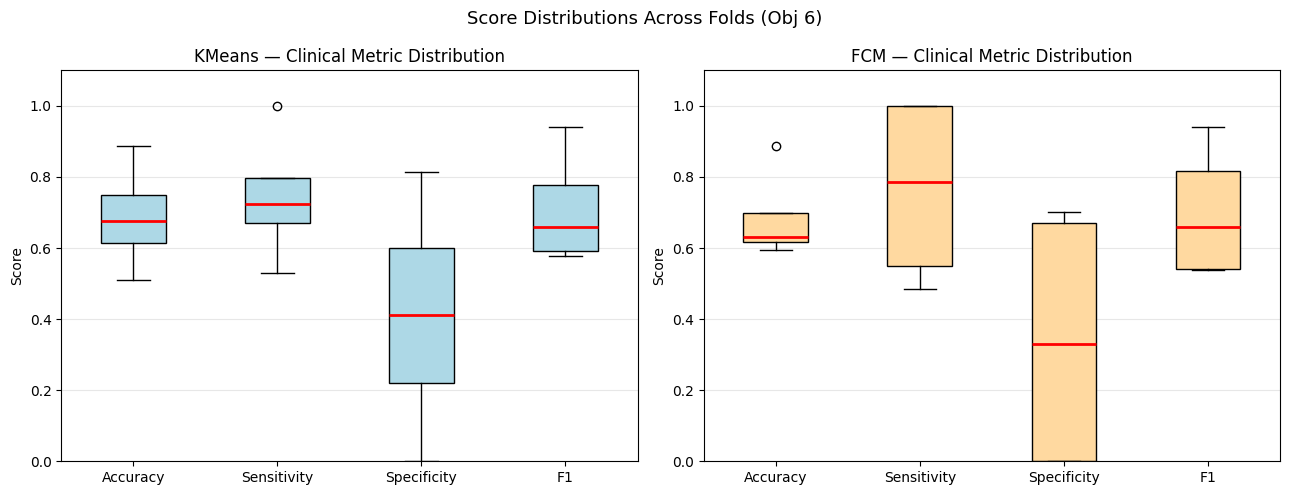


Zip saved → /content/clustering_final_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import zipfile

output_dir = "/content/clustering_results"
os.makedirs(output_dir, exist_ok=True)

# ─── Fig 1: Grouped bar — accuracy metrics ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metric_pairs = [
    ("Accuracy",    "km_acc",  "fcm_acc"),
    ("Sensitivity", "km_sens", "fcm_sens"),
    ("Specificity", "km_spec", "fcm_spec"),
    ("F1-Score",    "km_f1",   "fcm_f1"),
]
x     = np.arange(len(metric_pairs))
width = 0.35

km_means  = [results_df[p[1]].mean() for p in metric_pairs]
fcm_means = [results_df[p[2]].mean() for p in metric_pairs]
km_stds   = [results_df[p[1]].std()  for p in metric_pairs]
fcm_stds  = [results_df[p[2]].std()  for p in metric_pairs]

ax = axes[0]
b1 = ax.bar(x - width/2, km_means,  width, yerr=km_stds,  capsize=5,
            label="KMeans",  color="#4C72B0", edgecolor="black")
b2 = ax.bar(x + width/2, fcm_means, width, yerr=fcm_stds, capsize=5,
            label="FCM",     color="#DD8452", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels([p[0] for p in metric_pairs])
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Post-hoc Clinical Metrics (Obj 6)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar, m, s in zip(list(b1)+list(b2), km_means+fcm_means, km_stds+fcm_stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.02,
            f"{m:.3f}", ha="center", fontsize=8, fontweight="bold")

# ─── Fig 1b: Internal validity indices ───────────────────────────────────────
ax2 = axes[1]
int_metrics = [
    ("Silhouette↑", "km_sil",  "fcm_sil"),
    ("DB Index↓",   "km_db",   "fcm_db"),
]
x2     = np.arange(len(int_metrics))
km_m2  = [results_df[p[1]].mean() for p in int_metrics]
fcm_m2 = [results_df[p[2]].mean() for p in int_metrics]
km_s2  = [results_df[p[1]].std()  for p in int_metrics]
fcm_s2 = [results_df[p[2]].std()  for p in int_metrics]

b3 = ax2.bar(x2 - width/2, km_m2,  width, yerr=km_s2,  capsize=5,
             label="KMeans",  color="#4C72B0", edgecolor="black")
b4 = ax2.bar(x2 + width/2, fcm_m2, width, yerr=fcm_s2, capsize=5,
             label="FCM",     color="#DD8452", edgecolor="black")
ax2.set_xticks(x2); ax2.set_xticklabels([p[0] for p in int_metrics])
ax2.set_ylabel("Score"); ax2.set_title("Internal Validity Indices (Obj 6)")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/fig1_metric_comparison.png", dpi=150)
plt.show()

# ─── Fig 2: Per-fold line plots ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
folds = results_df["fold"].values

def plot_line(ax, metric_km, metric_fcm, title, ylabel):
    ax.plot(folds, results_df[metric_km],  marker="o", label="KMeans", linewidth=2)
    ax.plot(folds, results_df[metric_fcm], marker="s", label="FCM",    linewidth=2)
    ax.axhline(results_df[metric_km].mean(),  linestyle="--", color="#4C72B0", alpha=0.5)
    ax.axhline(results_df[metric_fcm].mean(), linestyle="--", color="#DD8452", alpha=0.5)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xlabel("Fold"); ax.set_xticks(folds)
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)

plot_line(axes[0,0], "km_acc",  "fcm_acc",  "Accuracy per Fold",    "Accuracy")
plot_line(axes[0,1], "km_f1",   "fcm_f1",   "F1-Score per Fold",    "F1")
plot_line(axes[1,0], "km_sens", "fcm_sens", "Sensitivity per Fold", "Sensitivity")
plot_line(axes[1,1], "km_spec", "fcm_spec", "Specificity per Fold", "Specificity")
plt.suptitle("Per-Fold Clinical Metrics — KMeans vs FCM", fontsize=13)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig2_per_fold_clinical.png", dpi=150)
plt.show()

# ─── Fig 3: Silhouette per fold + CH score ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(folds - 0.2, results_df["km_sil"],  0.4,
            label="KMeans", color="#4C72B0", edgecolor="black")
axes[0].bar(folds + 0.2, results_df["fcm_sil"], 0.4,
            label="FCM",    color="#DD8452", edgecolor="black")
axes[0].axhline(results_df["km_sil"].mean(),  linestyle="--", color="#4C72B0", alpha=0.6)
axes[0].axhline(results_df["fcm_sil"].mean(), linestyle="--", color="#DD8452", alpha=0.6)
axes[0].set_title("Silhouette Score per Fold (↑ better)")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Silhouette")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(folds - 0.2, results_df["km_db"],  0.4,
            label="KMeans", color="#4C72B0", edgecolor="black")
axes[1].bar(folds + 0.2, results_df["fcm_db"], 0.4,
            label="FCM",    color="#DD8452", edgecolor="black")
axes[1].set_title("Davies-Bouldin Index per Fold (↓ better)")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("DB Index")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(folds - 0.2, results_df["km_ch"],  0.4,
            label="KMeans", color="#4C72B0", edgecolor="black")
axes[2].bar(folds + 0.2, results_df["fcm_ch"], 0.4,
            label="FCM",    color="#DD8452", edgecolor="black")
axes[2].set_title("Calinski-Harabasz Score per Fold (↑ better)")
axes[2].set_xlabel("Fold"); axes[2].set_ylabel("CH Score")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Internal Validity Indices — Objective 6", fontsize=13)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig3_internal_indices.png", dpi=150)
plt.show()

# ─── Fig 4: PCA components & hyperparameter selection per fold ───────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(folds, results_df["n_pca"], color="#55A868", edgecolor="black")
axes[0].set_title("PCA Components Retained per Fold (95% var)")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("# Components")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(folds, results_df["best_k"], color="#4C72B0", edgecolor="black")
axes[1].set_title("Best KMeans k per Fold")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("k")
axes[1].set_yticks(range(2, 10)); axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(folds - 0.2, results_df["best_c"], 0.4,
            color="#DD8452", edgecolor="black", label="c (clusters)")
ax_r = axes[2].twinx()
ax_r.bar(folds + 0.2, results_df["best_m"], 0.4,
         color="#C44E52", edgecolor="black", alpha=0.6, label="m (fuzziness)")
axes[2].set_title("Best FCM c and m per Fold")
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("c"); ax_r.set_ylabel("m")
axes[2].legend(loc="upper left"); ax_r.legend(loc="upper right")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Hyperparameter Selection & Dimensionality Reduction (Obj 3 & 5)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig4_hyperparams_pca.png", dpi=150)
plt.show()

# ─── Fig 5: Box plots — score distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

km_data  = [results_df["km_acc"],  results_df["km_sens"],
            results_df["km_spec"], results_df["km_f1"]]
fcm_data = [results_df["fcm_acc"], results_df["fcm_sens"],
            results_df["fcm_spec"],results_df["fcm_f1"]]
xlabels  = ["Accuracy", "Sensitivity", "Specificity", "F1"]

bp1 = axes[0].boxplot(km_data,  labels=xlabels, patch_artist=True,
                       medianprops=dict(color="red", linewidth=2))
for p in bp1["boxes"]: p.set_facecolor("lightblue")
axes[0].set_title("KMeans — Clinical Metric Distribution")
axes[0].set_ylabel("Score"); axes[0].set_ylim(0, 1.1)
axes[0].grid(axis="y", alpha=0.3)

bp2 = axes[1].boxplot(fcm_data, labels=xlabels, patch_artist=True,
                       medianprops=dict(color="red", linewidth=2))
for p in bp2["boxes"]: p.set_facecolor("#FFD9A0")
axes[1].set_title("FCM — Clinical Metric Distribution")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Score Distributions Across Folds (Obj 6)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig5_boxplots.png", dpi=150)
plt.show()

# ─── Save CSVs ────────────────────────────────────────────────────────────────
results_df.to_csv(f"{output_dir}/fold_results.csv", index=False)
summary.to_csv(f"{output_dir}/summary_results.csv")

# ─── Zip everything ───────────────────────────────────────────────────────────
zip_path = "/content/clustering_final_results.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in os.listdir(output_dir):
        zf.write(os.path.join(output_dir, fname), fname)
    # Include preprocessing check if it exists
    if os.path.exists("preprocessing_check.png"):
        zf.write("preprocessing_check.png", "preprocessing_check.png")

print(f"\nZip saved → {zip_path}")

# ─── Auto-download ────────────────────────────────────────────────────────────
from google.colab import files
files.download(zip_path)
